# Marine Life Classification, Detection & Few-Shot Recognition

*Introduction to Vision and Robotics (AI'24) — course project*

Three tasks on a marine-life dataset (`fish`, `jelly`, `shark`, `tuna`, `whale`):

1. **Classification** — predict the species of an image (Xception, transfer learning).
2. **Detection** — box every `fish / jelly / shark / tuna` instance (YOLOv8).
3. **Few-shot recognition** — identify *individual whales* (Siamese network + triplet loss).

Plus an end-to-end inference pipeline and a bonus whale-tail segmentation step.

### How this notebook is organised

* **Imports** and **Definitions** at the very top — these are instant (no training).
* Then one training section per task. Each one **saves its model to disk** when it finishes.
* A final **"Reuse saved models"** section that loads everything back and runs inference —
  so once you've trained once, in later sessions you just run *Imports → Definitions →
  Reuse saved models* and skip all the training cells.

> The dataset is expected in the brief's layout:
> ```
> <DATA_ROOT>/
> ├── classification/   train|val  →  <class>/*.jpg
> ├── detection/        train|val  →  <class>/{*.jpg, *.txt}
> └── few-shot-learning/train|val  →  whale/<whale_id>/*.jpg
> ```


## 1. Imports

Everything the notebook needs, in one place. `ultralytics` (YOLO) is imported defensively
so that Parts 1 and 3 still work even if it isn't installed yet.

In [2]:
import os
import time
import random
import shutil

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, metrics
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# YOLO is only needed for Part 2. If it's missing: %pip install ultralytics
try:
    from ultralytics import YOLO
except ModuleNotFoundError:
    YOLO = None
    print("ultralytics not installed (needed only for Part 2). Run: %pip install ultralytics")

# Reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow", tf.__version__, "| NumPy", np.__version__)

TensorFlow 2.21.0 | NumPy 2.2.6


## 2. Configuration

Point `DATA_ROOT` at your dataset. Everything else is derived from it. Trained models are
written into `WORK_DIR`.

In [ ]:
DATA_ROOT = "/path/to/dataset"  # update this to your local dataset location

CLS_TRAIN = os.path.join(DATA_ROOT, "classification", "train")
CLS_VAL   = os.path.join(DATA_ROOT, "classification", "val")
DET_TRAIN = os.path.join(DATA_ROOT, "detection", "train")
DET_VAL   = os.path.join(DATA_ROOT, "detection", "val")
FS_TRAIN  = os.path.join(DATA_ROOT, "few-shot-learning", "train", "whale")
FS_VAL    = os.path.join(DATA_ROOT, "few-shot-learning", "val", "whale")

WORK_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
os.makedirs(WORK_DIR, exist_ok=True)

# Where each trained model gets saved (and reloaded from later).
CLF_PATH     = os.path.join(WORK_DIR, "marine_classifier.h5")
ENCODER_PATH = os.path.join(WORK_DIR, "whale_encoder.weights.h5")
YOLO_DIR     = os.path.join(WORK_DIR, "marine_detector")
YOLO_BEST    = os.path.join(YOLO_DIR, "weights", "best.pt")
YOLO_ROOT    = os.path.join(WORK_DIR, "yolo_dataset")

# Keras orders classes alphabetically, which matches this list.
CLASS_NAMES = ["fish", "jelly", "shark", "tuna", "whale"]
DET_CLASSES = ["fish", "jelly", "shark", "tuna"]

IMG_SIZE    = (224, 224)   # classifier input
FS_IMG_SIZE = (128, 128)   # few-shot input (smaller: triplets = 3x the images)

## 3. Definitions

All the functions and model builders, grouped together. Running this section is instant —
it only defines things. The training sections below call into these, and so does the
"Reuse saved models" section at the end.

### 3a. Classifier builder & helpers

In [5]:
def build_classifier(num_classes):
    """Xception backbone (frozen) + a small classification head."""
    augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.2),   # covers the lighting variation in the brief
    ], name="augmentation")

    backbone = Xception(include_top=False, weights="imagenet",
                        input_shape=IMG_SIZE + (3,))
    backbone.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = augmentation(inputs)
    x = xception_preprocess(x)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="marine_classifier")
    return model, backbone


def plot_history(*histories):
    acc, val_acc, loss, val_loss = [], [], [], []
    for h in histories:
        acc += h.history["accuracy"]; val_acc += h.history["val_accuracy"]
        loss += h.history["loss"];    val_loss += h.history["val_loss"]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    a1.plot(acc, label="train"); a1.plot(val_acc, label="val")
    a1.set_title("Accuracy"); a1.set_xlabel("epoch"); a1.legend()
    a2.plot(loss, label="train"); a2.plot(val_loss, label="val")
    a2.set_title("Loss"); a2.set_xlabel("epoch"); a2.legend()
    plt.tight_layout(); plt.show()


def classify_one(image_path):
    """Return (species_name, confidence) for a single image using clf_model."""
    arr = img_to_array(load_img(image_path, target_size=IMG_SIZE))[None, ...]
    probs = clf_model.predict(arr, verbose=0)[0]
    return CLASS_NAMES[int(np.argmax(probs))], float(np.max(probs))

### 3b. Detection: annotation converter

The dataset stores one `.txt` per image where each line is
`width, height, xmin, ymin, xmax, ymax` (image size + box corners) and the class is the
folder name. YOLO wants `class_id cx cy w h` normalised to [0, 1], so we convert.

In [6]:
def convert_split_to_yolo(src_split_dir, dst_root, split_name):
    img_out = os.path.join(dst_root, "images", split_name)
    lbl_out = os.path.join(dst_root, "labels", split_name)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    n = 0
    for class_id, class_name in enumerate(DET_CLASSES):
        class_dir = os.path.join(src_split_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        for img_name in os.listdir(class_dir):
            if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            stem = os.path.splitext(img_name)[0]
            txt_path = os.path.join(class_dir, stem + ".txt")
            if not os.path.isfile(txt_path):
                continue

            yolo_lines = []
            with open(txt_path) as f:
                for line in f:
                    line = line.strip().replace(",", " ")
                    if not line:
                        continue
                    W, H, xmin, ymin, xmax, ymax = map(float, line.split())
                    cx, cy = ((xmin + xmax) / 2) / W, ((ymin + ymax) / 2) / H
                    bw, bh = (xmax - xmin) / W, (ymax - ymin) / H
                    yolo_lines.append(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

            # Prefix with class name so repeated numbers across folders don't collide.
            out_stem = f"{class_name}_{stem}"
            shutil.copy(os.path.join(class_dir, img_name),
                        os.path.join(img_out, out_stem + os.path.splitext(img_name)[1]))
            with open(os.path.join(lbl_out, out_stem + ".txt"), "w") as f:
                f.write("\n".join(yolo_lines))
            n += 1
    print(f"  {split_name}: converted {n} images")

### 3c. Few-shot: encoder, Siamese network, triplet loss & inference helpers

`get_encoder(..., pretrained=False)` lets us rebuild the architecture *without*
re-downloading ImageNet weights when we're only going to load our own trained weights.

In [6]:
def read_image(base_dir, index, size=FS_IMG_SIZE):
    """Load one image given as (folder, filename) and resize it."""
    img = cv2.imread(os.path.join(base_dir, index[0], index[1]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, size)


def create_triplets(directory, max_files=10):
    """Build (anchor, positive, negative) triplets from the whale-ID folders."""
    triplets, folders = [], os.listdir(directory)
    for folder in folders:
        files = os.listdir(os.path.join(directory, folder))[:max_files]
        for i in range(len(files) - 1):
            for j in range(i + 1, len(files)):
                anchor, positive = (folder, files[i]), (folder, files[j])
                neg_folder = folder
                while neg_folder == folder:
                    neg_folder = random.choice(folders)
                neg_file = random.choice(os.listdir(os.path.join(directory, neg_folder)))
                triplets.append((anchor, positive, (neg_folder, neg_file)))
    random.shuffle(triplets)
    return triplets


def get_batch(base_dir, triplet_list, batch_size=128, preprocess=True):
    steps = len(triplet_list) // batch_size
    for i in range(steps + 1):
        a, p, n = [], [], []
        j = i * batch_size
        while j < (i + 1) * batch_size and j < len(triplet_list):
            ta, tp, tn = triplet_list[j]
            a.append(read_image(base_dir, ta))
            p.append(read_image(base_dir, tp))
            n.append(read_image(base_dir, tn))
            j += 1
        a, p, n = np.array(a), np.array(p), np.array(n)
        if preprocess:
            a, p, n = xception_preprocess(a), xception_preprocess(p), xception_preprocess(n)
        yield [a, p, n]


def get_encoder(input_shape, pretrained=True):
    """Xception backbone + embedding head producing an L2-normalised vector."""
    backbone = Xception(input_shape=input_shape,
                        weights="imagenet" if pretrained else None,
                        include_top=False, pooling="avg")
    for layer in backbone.layers[:-27]:
        layer.trainable = False
    return Sequential([
        backbone,
        layers.Dense(512, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1)),
    ], name="encoder")


class DistanceLayer(layers.Layer):
    """Squared distances (anchor-positive) and (anchor-negative)."""
    def call(self, anchor, positive, negative):
        ap = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
        an = tf.reduce_sum(tf.square(anchor - negative), axis=-1)
        return ap, an


def build_siamese(input_shape=FS_IMG_SIZE + (3,), pretrained=True):
    encoder = get_encoder(input_shape, pretrained=pretrained)
    a_in = layers.Input(input_shape, name="anchor")
    p_in = layers.Input(input_shape, name="positive")
    n_in = layers.Input(input_shape, name="negative")
    distances = DistanceLayer()(encoder(a_in), encoder(p_in), encoder(n_in))
    network = Model([a_in, p_in, n_in], distances, name="siamese_net")
    return network, encoder


class SiameseModel(Model):
    """Wraps the Siamese network with triplet loss: max(d_ap - d_an + margin, 0)."""
    def __init__(self, network, margin=0.5):
        super().__init__()
        self.network = network
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")

    def call(self, inputs):
        return self.network(inputs)

    def _loss(self, data):
        ap, an = self.network(data)
        return tf.reduce_mean(tf.maximum(ap - an + self.margin, 0.0))

    def train_step(self, data):
        if isinstance(data, (tuple, list)):
            data = data[0]  # strip Keras-added (y, sample_weight) slots
        with tf.GradientTape() as tape:
            loss = self._loss(data)
        grads = tape.gradient(loss, self.network.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.network.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        self.loss_tracker.update_state(self._loss(data))
        return {"loss": self.loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker]


def embed(images):
    """Run the trained encoder on a batch of images -> embeddings."""
    return encoder.predict(images, verbose=0)


def build_reference_gallery(gallery_dir, refs_per_whale=1):
    """One averaged embedding per whale ID — the lookup table for identification."""
    gallery = {}
    for whale_id in os.listdir(gallery_dir):
        folder = os.path.join(gallery_dir, whale_id)
        if not os.path.isdir(folder):
            continue
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))][:refs_per_whale]
        imgs = np.array([read_image(gallery_dir, (whale_id, f)) for f in files])
        gallery[whale_id] = embed(xception_preprocess(imgs)).mean(axis=0)
    return gallery


def identify_whale(image_path, gallery):
    """Return (closest_whale_id, distance) for a query image."""
    img = cv2.resize(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB), FS_IMG_SIZE)
    q = embed(xception_preprocess(img[None, ...]))[0]
    best_id, best_dist = None, float("inf")
    for whale_id, ref in gallery.items():
        d = np.sum((q - ref) ** 2)
        if d < best_dist:
            best_dist, best_id = d, whale_id
    return best_id, best_dist

### 3d. End-to-end pipeline & bonus segmentation

In [17]:
def run_pipeline(image_path, gallery):
    """Classify -> then detect (4 species) or identify the whale."""
    species, conf = classify_one(image_path)
    print(f"[1] Classified as '{species}' (confidence {conf:.2f})")

    plt.figure(figsize=(7, 7))
    if species == "whale":
        whale_id, dist = identify_whale(image_path, gallery)
        print(f"[2] Whale identified as ID '{whale_id}' (distance {dist:.3f})")
        plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
        plt.title(f"whale — ID {whale_id}")
    else:
        result = det_model.predict(image_path, conf=0.25, verbose=False)[0]
        print(f"[2] Detected {len(result.boxes)} instance(s) of '{species}'")
        plt.imshow(result.plot()[:, :, ::-1])
        plt.title(f"{species} — detection")
    plt.axis("off"); plt.show()


def segment_whale_tail(image_path):
    """Classical segmentation of a whale tail + outline length (bonus)."""
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 50, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.erode(cv2.dilate(thresh, kernel, 1), kernel, 1)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if cv2.contourArea(c) > 1000]
    if not contours:
        print("No tail-like contour found."); return
    tail = max(contours, key=cv2.contourArea)

    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [tail], -1, 255, thickness=cv2.FILLED)
    segmented = cv2.bitwise_and(image, image, mask=mask)
    perimeter = cv2.arcLength(tail, closed=True)

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
    a1.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB));     a1.set_title("original");  a1.axis("off")
    a2.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)); a2.set_title("segmented tail"); a2.axis("off")
    plt.tight_layout(); plt.show()
    print(f"Whale tail outline length: {perimeter:.1f} px")

# Part 1 — Train the classifier

⏱️ **Training cell below is slow on CPU.** Run it once; afterwards the model is saved and
you can reload it from the "Reuse saved models" section instead of retraining.

In [18]:
BATCH = 32
train_ds = keras.utils.image_dataset_from_directory(
    CLS_TRAIN, image_size=IMG_SIZE, batch_size=BATCH, label_mode="int",
    shuffle=True, seed=SEED)
val_ds = keras.utils.image_dataset_from_directory(
    CLS_VAL, image_size=IMG_SIZE, batch_size=BATCH, label_mode="int", shuffle=False)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

Found 1162 files belonging to 5 classes.
Found 308 files belonging to 5 classes.
Classes: ['Jelly', 'fish', 'shark', 'tuna', 'whale']


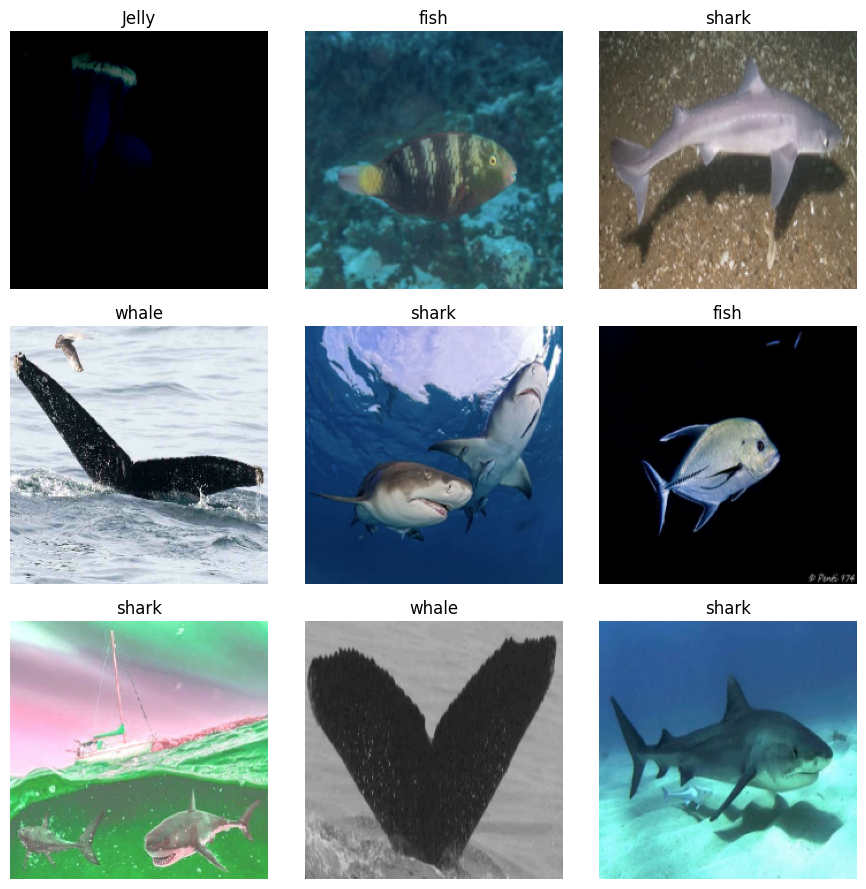

In [19]:
# Peek at a batch to confirm paths/labels are right before training.
plt.figure(figsize=(9, 9))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]]); plt.axis("off")
plt.tight_layout(); plt.show()

In [20]:
clf_model, clf_backbone = build_classifier(len(class_names))
clf_model.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
clf_model.summary()

Model: "marine_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,871,725 (79.62 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [21]:
# Class weights to counter the imbalance noted in the brief.
counts = [len([f for f in os.listdir(os.path.join(CLS_TRAIN, n))
               if f.lower().endswith((".jpg", ".jpeg", ".png"))]) for n in class_names]
print("Images per class:", dict(zip(class_names, counts)))
y_all = np.concatenate([[i] * c for i, c in enumerate(counts)])
weights = compute_class_weight("balanced", classes=np.arange(len(class_names)), y=y_all)
class_weight = {i: w for i, w in enumerate(weights)}
print("Class weights:", class_weight)

Images per class: {'Jelly': 199, 'fish': 322, 'shark': 111, 'tuna': 70, 'whale': 460}
Class weights: {0: np.float64(1.1678391959798995), 1: np.float64(0.7217391304347827), 2: np.float64(2.0936936936936936), 3: np.float64(3.32), 4: np.float64(0.5052173913043478)}


In [22]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                  restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
]

t0 = time.time()
history = clf_model.fit(train_ds, validation_data=val_ds, epochs=25,
                        class_weight=class_weight, callbacks=callbacks)
print(f"\nClassification training time: {time.time() - t0:.1f} s")

Epoch 1/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.7599 - loss: 0.8555 - val_accuracy: 0.9481 - val_loss: 0.2468 - learning_rate: 0.0010
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9157 - loss: 0.3874 - val_accuracy: 0.9448 - val_loss: 0.2077 - learning_rate: 0.0010
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.9260 - loss: 0.3165 - val_accuracy: 0.9545 - val_loss: 0.1842 - learning_rate: 0.0010
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.9355 - loss: 0.2831 - val_accuracy: 0.9675 - val_loss: 0.1634 - learning_rate: 0.0010
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9286 - loss: 0.2661 - val_accuracy: 0.9675 - val_loss: 0.1633 - learning_rate: 0.0010
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9389 - loss: 0.2424 - val_accuracy: 0.9643 - val_loss: 0.1660 - learning_rate: 0.0010
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9312 - loss: 0.2468 - val_accuracy: 

fine-tuning: unfreeze the top of Xception with a tiny learning rate.

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.9045 - loss: 0.5447 - val_accuracy: 0.9643 - val_loss: 0.1346 - learning_rate: 1.0000e-05
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.9251 - loss: 0.3896 - val_accuracy: 0.9610 - val_loss: 0.1394 - learning_rate: 1.0000e-05
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.9380 - loss: 0.3204 - val_accuracy: 0.9610 - val_loss: 0.1390 - learning_rate: 1.0000e-05
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.9441 - loss: 0.2890 - val_accuracy: 0.9610 - val_loss: 0.1387 - learning_rate: 5.0000e-06
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.9509 - loss: 0.2623 - val_accuracy: 0.9610 - val_loss: 0.1350 - learning_rate: 5.0000e-06

Fine-tuning time: 567.9 s


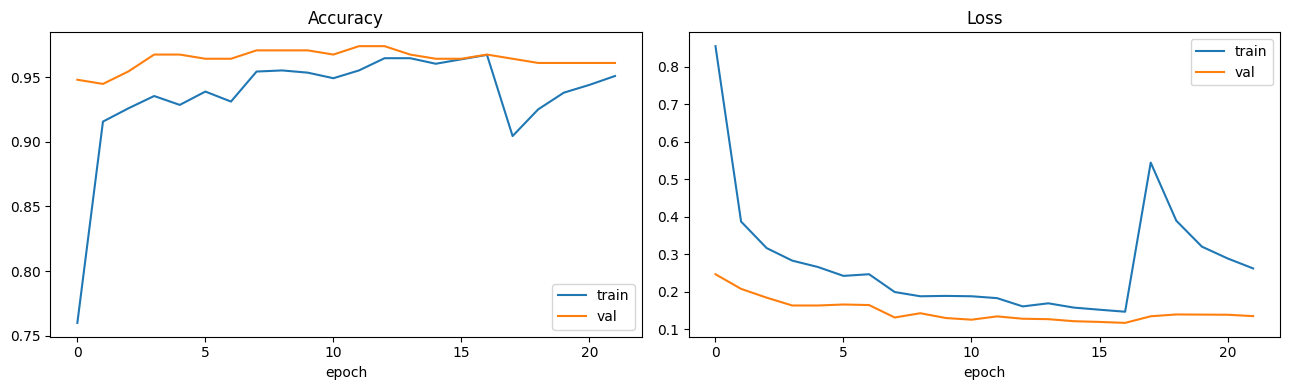

In [23]:
clf_backbone.trainable = True
for layer in clf_backbone.layers[:-30]:
    layer.trainable = False

clf_model.compile(optimizer=Adam(1e-5), loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
t0 = time.time()
history_ft = clf_model.fit(train_ds, validation_data=val_ds, epochs=10,
                           class_weight=class_weight, callbacks=callbacks)
print(f"\nFine-tuning time: {time.time() - t0:.1f} s")
plot_history(history, history_ft)

### Validation metrics

Validation accuracy: 0.9643

              precision    recall  f1-score   support

       Jelly       0.75      1.00      0.86         9
        fish       0.99      0.94      0.96        97
       shark       0.89      0.89      0.89        27
        tuna       0.80      0.89      0.84        18
       whale       1.00      1.00      1.00       157

    accuracy                           0.96       308
   macro avg       0.89      0.94      0.91       308
weighted avg       0.97      0.96      0.97       308



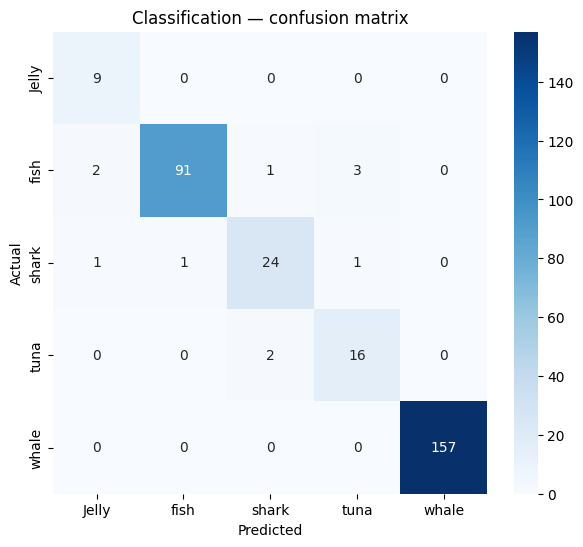

In [24]:
y_true, y_pred = [], []
for images, labels in val_ds:
    y_pred.extend(np.argmax(clf_model.predict(images, verbose=0), axis=1))
    y_true.extend(labels.numpy())
y_true, y_pred = np.array(y_true), np.array(y_pred)

print(f"Validation accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Classification — confusion matrix")
plt.show()

### 💾 Save the classifier

In [25]:
clf_model.save(CLF_PATH)
print("Saved classifier ->", CLF_PATH)

Saved classifier -> .\marine_classifier.h5


# Part 2 — Train the detector (YOLOv8)

⏱️ Slow on CPU. Trains once, then YOLO's `best.pt` is saved and reloadable.

In [9]:
print("Building YOLO dataset...")
convert_split_to_yolo(DET_TRAIN, YOLO_ROOT, "train")
convert_split_to_yolo(DET_VAL,   YOLO_ROOT, "val")

data_yaml = os.path.join(YOLO_ROOT, "data.yaml")
with open(data_yaml, "w") as f:
    f.write(f"path: {os.path.abspath(YOLO_ROOT)}\n")
    f.write("train: images/train\n")
    f.write("val: images/val\n")
    f.write(f"nc: {len(DET_CLASSES)}\n")
    f.write(f"names: {DET_CLASSES}\n")
print(open(data_yaml).read())

Building YOLO dataset...
  train: converted 702 images
  val: converted 151 images
path: c:\Users\Lenovo\Downloads\yolo_dataset
train: images/train
val: images/val
nc: 4
names: ['fish', 'jelly', 'shark', 'tuna']



In [3]:
print(YOLO)   # should show the ultralytics class, NOT None

<class 'ultralytics.models.yolo.model.YOLO'>


In [10]:
det_model = YOLO("yolov8n.pt")   # downloads pretrained weights on first run
t0 = time.time()
det_model.train(data=data_yaml, epochs=50, imgsz=640, batch=16,
                project=WORK_DIR, name="marine_detector", seed=SEED)
print(f"\nDetection training time: {time.time() - t0:.1f} s")
print("Best weights saved at:", YOLO_BEST)

Ultralytics 8.4.67  Python-3.10.18 torch-2.12.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=.\yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=marine_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

### Validation metrics & sample predictions

In [11]:
metrics_det = det_model.val()
print(f"mAP@0.5      : {metrics_det.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics_det.box.map:.4f}")
print(f"precision    : {metrics_det.box.mp:.4f}")
print(f"recall       : {metrics_det.box.mr:.4f}")

Ultralytics 8.4.67  Python-3.10.18 torch-2.12.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.3 ms, read: 229.5133.0 MB/s, size: 38.2 KB)
val: Scanning C:\Users\Lenovo\Downloads\yolo_dataset\labels\val.cache... 151 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 151/151  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.2s/it 12.4s.3s
                   all        151        374      0.808      0.665      0.744      0.493
                  fish         97        270      0.833      0.733      0.834      0.562
                 jelly          9         40      0.754      0.325      0.397       0.13
                 shark         27         41      0.898      0.645      0.786      0.532
                  tuna         18         23      0.748      0.957      0.958      0.746
Speed: 1.2ms preprocess, 71.8ms in

In [12]:
val_img_dir = os.path.join(YOLO_ROOT, "images", "val")
samples = [os.path.join(val_img_dir, f) for f in os.listdir(val_img_dir)[:6]]
results = det_model.predict(samples, conf=0.25, verbose=False)

plt.figure(figsize=(15, 8))
for i, r in enumerate(results):
    plt.subplot(2, 3, i + 1)
    plt.imshow(r.plot()[:, :, ::-1]); plt.axis("off")
plt.tight_layout(); plt.show()

<Figure size 1500x800 with 6 Axes>

# Part 3 — Train the few-shot whale model

⏱️ Slow on CPU. The encoder's weights are saved at the end and reloaded later.

In [8]:
train_triplets = create_triplets(FS_TRAIN)
val_triplets   = create_triplets(FS_VAL)
print(f"Train triplets: {len(train_triplets)} | Val triplets: {len(val_triplets)}")

Train triplets: 1794 | Val triplets: 600


In [16]:
# Sanity check: first two columns = same whale, third = different whale.
rows = 4
fig, axes = plt.subplots(rows, 3, figsize=(9, 3 * rows))
for a, p, n in [next(get_batch(FS_TRAIN, train_triplets, batch_size=rows, preprocess=False))]:
    for i in range(rows):
        axes[i, 0].imshow(a[i]); axes[i, 0].set_title("anchor");   axes[i, 0].axis("off")
        axes[i, 1].imshow(p[i]); axes[i, 1].set_title("positive"); axes[i, 1].axis("off")
        axes[i, 2].imshow(n[i]); axes[i, 2].set_title("negative"); axes[i, 2].axis("off")
plt.tight_layout(); plt.show()

<Figure size 900x1200 with 12 Axes>

In [10]:
siamese_network, encoder = build_siamese(pretrained=True)
siamese_model = SiameseModel(siamese_network, margin=0.5)
siamese_model.compile(optimizer=Adam(1e-4))
siamese_network.summary()


def evaluate_triplets(base_dir, triplet_list, batch_size=128):
    pos, neg = [], []
    for data in get_batch(base_dir, triplet_list, batch_size=batch_size):
        ap, an = siamese_model.predict(data, verbose=0)
        pos.extend(ap); neg.extend(an)
    pos, neg = np.array(pos), np.array(neg)
    return np.mean(pos < neg), pos.mean(), neg.mean()

Model: "siamese_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, 128)       │ 22,077,864 │ anchor[0][0],     │
│ (Sequential)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distance_layer      │ [(None), (None)]  │          0 │ encoder[0][0],    │
│ (DistanceLayer)     │                   │            │ encoder[1][0],    │
│                     │                   │            │ encoder[2][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,077,864 (84.22 MB)

 Trainable params: 9,617,208 (36.69 MB)

 Non-trainable params: 12,460,656 (47.53 MB)

In [13]:
EPOCHS, BATCH_SIZE = 20, 16
best_acc = 0.0
train_loss_hist, val_acc_hist = [], []

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    losses = []
    for data in get_batch(FS_TRAIN, train_triplets, batch_size=BATCH_SIZE):
        with tf.GradientTape() as tape:
            ap, an = siamese_network(data, training=True)
            loss = tf.reduce_mean(tf.maximum(ap - an + siamese_model.margin, 0.0))
        grads = tape.gradient(loss, siamese_network.trainable_weights)
        siamese_model.optimizer.apply_gradients(zip(grads, siamese_network.trainable_weights))
        losses.append(float(loss))
    epoch_loss = float(np.mean(losses))
    train_loss_hist.append(epoch_loss)

    acc, ap_m, an_m = evaluate_triplets(FS_VAL, val_triplets, BATCH_SIZE)
    val_acc_hist.append(acc)
    print(f"Epoch {epoch:2d}/{EPOCHS}  loss={epoch_loss:.4f}  val_acc={acc:.4f}  "
          f"(ap={ap_m:.3f}, an={an_m:.3f})  [{int(time.time()-t0)}s]")

    if acc >= best_acc:
        best_acc = acc
        encoder.save_weights(ENCODER_PATH)

print(f"\nFew-shot training time: {time.time() - t_start:.1f} s | best val_acc={best_acc:.4f}")
print("Saved encoder weights ->", ENCODER_PATH)


Epoch  1/20  loss=0.2745  val_acc=0.7150  (ap=0.783, an=1.104)  [771s]
Epoch  2/20  loss=0.1828  val_acc=0.7233  (ap=0.932, an=1.279)  [776s]
Epoch  3/20  loss=0.1308  val_acc=0.7833  (ap=0.818, an=1.265)  [777s]
Epoch  4/20  loss=0.0939  val_acc=0.7767  (ap=0.815, an=1.265)  [805s]
Epoch  5/20  loss=0.0659  val_acc=0.7833  (ap=0.826, an=1.287)  [790s]
Epoch  6/20  loss=0.0499  val_acc=0.7800  (ap=0.807, an=1.279)  [839s]
Epoch  7/20  loss=0.0377  val_acc=0.7950  (ap=0.776, an=1.270)  [840s]
Epoch  8/20  loss=0.0269  val_acc=0.8017  (ap=0.805, an=1.294)  [912s]
Epoch  9/20  loss=0.0200  val_acc=0.7883  (ap=0.812, an=1.281)  [857s]
Epoch 10/20  loss=0.0185  val_acc=0.7883  (ap=0.816, an=1.299)  [754s]
Epoch 11/20  loss=0.0131  val_acc=0.7950  (ap=0.781, an=1.288)  [723s]
Epoch 12/20  loss=0.0104  val_acc=0.8167  (ap=0.813, an=1.322)  [706s]
Epoch 13/20  loss=0.0105  val_acc=0.7900  (ap=0.834, an=1.313)  [690s]
Epoch 14/20  loss=0.0089  val_acc=0.8133  (ap=0.773, an=1.309)  [743s]
Epoch 

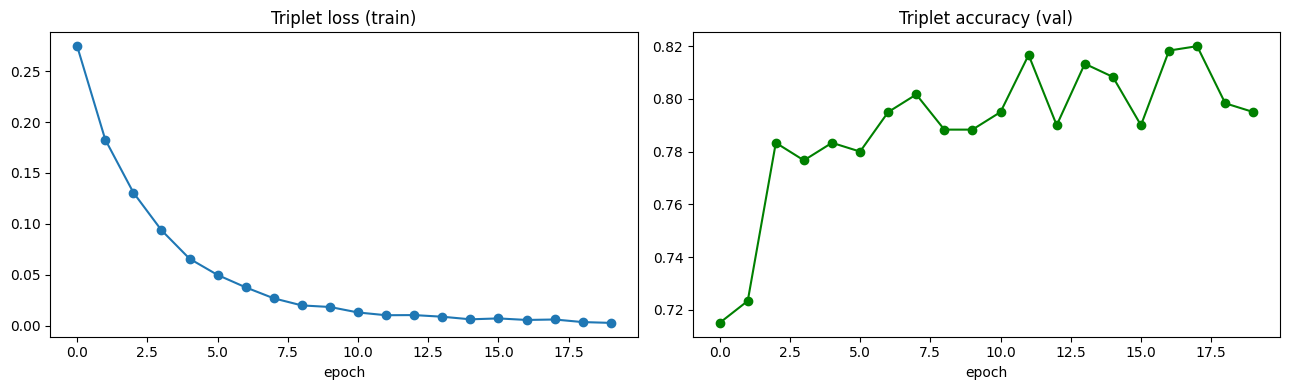

In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(train_loss_hist, marker="o"); a1.set_title("Triplet loss (train)"); a1.set_xlabel("epoch")
a2.plot(val_acc_hist, marker="o", color="green"); a2.set_title("Triplet accuracy (val)"); a2.set_xlabel("epoch")
plt.tight_layout(); plt.show()

### Whale re-identification accuracy

Reload the best encoder, build a reference gallery from the (unseen) validation whales,
and score every remaining image against it.

In [17]:
encoder.load_weights(ENCODER_PATH)
REFS_PER_WHALE = 5
gallery = build_reference_gallery(FS_VAL, refs_per_whale=REFS_PER_WHALE)

correct_top1 = correct_top5 = total = 0
for whale_id in os.listdir(FS_VAL):
    folder = os.path.join(FS_VAL, whale_id)
    if not os.path.isdir(folder):
        continue
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    for f in files[REFS_PER_WHALE:]:           # skip the images used as gallery references
        img = read_image(FS_VAL, (whale_id, f))
        q = embed(xception_preprocess(img[None, ...]))[0]
        ranked = sorted(gallery.items(), key=lambda kv: np.sum((q - kv[1]) ** 2))
        top5_ids = [wid for wid, _ in ranked[:5]]
        correct_top1 += (top5_ids[0] == whale_id)
        correct_top5 += (whale_id in top5_ids)
        total += 1

print(f"Whale re-identification top-1 accuracy: {correct_top1}/{total} = {correct_top1/max(total,1):.4f}")
print(f"Whale re-identification top-5 accuracy: {correct_top5}/{total} = {correct_top5/max(total,1):.4f}")

Whale re-identification top-1 accuracy: 34/72 = 0.4722
Whale re-identification top-5 accuracy: 66/72 = 0.9167
